In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score
)

from sklearn.ensemble import RandomForestRegressor

In [2]:
df_clean = pd.read_csv('taxy_nyc_clean.csv')

In [3]:
df_clean.info()
df_clean.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440078 entries, 0 to 1440077
Data columns (total 28 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   Unnamed: 0          1440078 non-null  int64  
 1   id                  1440078 non-null  object 
 2   vendor_id           1440078 non-null  int64  
 3   pickup_datetime     1440078 non-null  object 
 4   dropoff_datetime    1440078 non-null  object 
 5   passenger_count     1440078 non-null  int64  
 6   pickup_longitude    1440078 non-null  float64
 7   pickup_latitude     1440078 non-null  float64
 8   dropoff_longitude   1440078 non-null  float64
 9   dropoff_latitude    1440078 non-null  float64
 10  store_and_fwd_flag  1440078 non-null  object 
 11  trip_duration       1440078 non-null  int64  
 12  pickup_month        1440078 non-null  int64  
 13  pickup_day          1440078 non-null  int64  
 14  pickup_hour         1440078 non-null  int64  
 15  pickup_weekday 

,Unnamed: 0,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration,pickup_month,pickup_day,...,is_weekend,dropoff_month,dropoff_day,dropoff_hour,dropoff_weekday,dropoff_weekend,duration_trip_calc,distance_km,speed,trip_duration_min
count,1.440078e+06,1.440078e+06,1.440078e+06,1.440078e+06,1.440078e+06,1.440078e+06,1.440078e+06,1.440078e+06,1.440078e+06,1.440078e+06,...,1.440078e+06,1.440078e+06,1.440078e+06,1.440078e+06,1.440078e+06,1.440078e+06,1.440078e+06,1.440078e+06,1.440078e+06,1.440078e+06
mean,7.200385e+05,1.534429e+00,1.665042e+00,-7.397363e+01,4.075101e+01,-7.397353e+01,4.075189e+01,8.418033e+02,3.516548e+00,1.550461e+01,...,2.851401e-01,3.516859e+00,1.550515e+01,1.360760e+01,3.053623e+00,2.864400e-01,8.418033e+02,3.471270e+00,1.447794e+01,1.403005e+01
std,4.157149e+05,4.988134e-01,1.314188e+00,3.769891e-02,2.784049e-02,3.556647e-02,3.219144e-02,6.529817e+02,1.680896e+00,8.703245e+00,...,4.514813e-01,1.681067e+00,8.703246e+00,6.479706e+00,1.956192e+00,4.520977e-01,6.529817e+02,3.943730e+00,7.629358e+00,1.088303e+01
min,0.000000e+00,1.000000e+00,1.000000e+00,-7.433240e+01,4.039825e+01,-7.477543e+01,4.027103e+01,6.100000e+01,1.000000e+00,1.000000e+00,...,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.100000e+01,1.000080e-01,5.107940e-02,1.016667e+00
25%,3.600192e+05,1.000000e+00,1.000000e+00,-7.399187e+01,4.073743e+01,-7.399133e+01,4.073596e+01,4.020000e+02,2.000000e+00,8.000000e+00,...,0.000000e+00,2.000000e+00,8.000000e+00,9.000000e+00,1.000000e+00,0.000000e+00,4.020000e+02,1.255929e+00,9.226887e+00,6.700000e+00
50%,7.200385e+05,2.000000e+00,1.000000e+00,-7.398178e+01,4.075414e+01,-7.397978e+01,4.075457e+01,6.660000e+02,4.000000e+00,1.500000e+01,...,0.000000e+00,4.000000e+00,1.500000e+01,1.400000e+01,3.000000e+00,0.000000e+00,6.660000e+02,2.117549e+00,1.285705e+01,1.110000e+01
75%,1.080058e+06,2.000000e+00,2.000000e+00,-7.396750e+01,4.076836e+01,-7.396316e+01,4.076983e+01,1.077000e+03,5.000000e+00,2.300000e+01,...,1.000000e+00,5.000000e+00,2.300000e+01,1.900000e+01,5.000000e+00,1.000000e+00,1.077000e+03,3.908746e+00,1.788562e+01,1.795000e+01
max,1.440077e+06,2.000000e+00,6.000000e+00,-7.323800e+01,4.169680e+01,-7.272073e+01,4.169335e+01,7.191000e+03,6.000000e+00,3.100000e+01,...,1.000000e+00,7.000000e+00,3.100000e+01,2.300000e+01,6.000000e+00,1.000000e+00,7.191000e+03,9.758621e+01,9.953154e+01,1.198500e+02


In [4]:
df_clean = df_clean.drop('Unnamed: 0', axis = 1)

In [5]:
#Avendo un dataset con un milione di righe utilizziamo un df sample con 1/3 delle righe del dataset per velocizzare il processo
df_sample = df_clean.sample(n = 300000, random_state = 42)
print(f"Le dimensioni sono adesso: {df_sample.shape[0]} righe e {df_sample.shape[1]} colonne")
df_sample.head()

Le dimensioni sono adesso: 300000 righe e 27 colonne


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,...,dropoff_day,dropoff_hour,dropoff_weekday,dropoff_weekend,duration_trip_calc,day_of_the_week,month_name,distance_km,speed,trip_duration_min
931772,id0936703,2,2016-05-26 20:55:08,2016-05-26 21:10:13,2,-73.986282,40.747147,-73.979607,40.714745,N,...,26,21,3,0,905.0,Thursday,May,3.646588,14.505766,15.083333
1308968,id3821288,2,2016-05-15 07:57:25,2016-05-15 08:00:26,1,-73.989227,40.758533,-73.987411,40.765324,N,...,15,8,6,1,181.0,Sunday,May,0.770364,15.322151,3.016667
690799,id1398494,2,2016-02-16 17:46:19,2016-02-16 17:51:56,6,-73.982300,40.745548,-73.977631,40.745483,N,...,16,17,1,0,337.0,Tuesday,February,0.393413,4.202631,5.616667
1022597,id2417795,2,2016-02-20 11:17:10,2016-02-20 11:25:52,3,-73.971672,40.750603,-73.986786,40.745327,N,...,20,11,5,1,522.0,Saturday,February,1.401838,9.667845,8.700000
479179,id1249840,2,2016-03-11 17:57:56,2016-03-11 18:01:11,2,-74.012268,40.702511,-74.004303,40.707390,N,...,11,18,4,0,195.0,Friday,March,0.863205,15.936088,3.250000


In [6]:
feature = ["passenger_count",
           "distance_km",
           "pickup_longitude",
           "pickup_latitude",
           "dropoff_longitude",
           "dropoff_latitude",
           "is_weekend",
           "pickup_hour",
           "pickup_month",
           "pickup_weekday",
           "vendor_id"
          ]

X = df_sample[feature]
y = df_sample['trip_duration']

print(f"Le dimensioni di X sono: {X.shape[0]} e {X.shape[1]}")
print(f"Della variabile target sono: {y.shape}")
print(f"Feature:\n {X.columns.tolist()}")

Le dimensioni di X sono: 300000 e 11
Della variabile target sono: (300000,)
Feature:
 ['passenger_count', 'distance_km', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'is_weekend', 'pickup_hour', 'pickup_month', 'pickup_weekday', 'vendor_id']


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

print("Data split")
print("=" * 80)

print(f"Abbiamo il traning set: {X_train.shape[0]} che è il {X_train.shape[0] / len(X) *100:.2f}%")
print(f"Abbiamo il test set: {X_test.shape[0]} che è il {X_test.shape[0] / len(X) *100:.2f}%")

Data split
Abbiamo il traning set: 240000 che è il 80.00%
Abbiamo il test set: 60000 che è il 20.00%


In [8]:
#Facciamo il Random Forest
model_rf = RandomForestRegressor(n_estimators = 100, max_depth = 10,        
    min_samples_split = 5, 
    n_jobs = -1,           
    random_state = 42)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2 = r2_score(y_test, y_pred_rf)

print("=" * 80)
print(f"MAE:  {mae:.2f} secondi")
print(f"RMSE: {rmse:.2f} secondi")
print(f"R²:   {r2:.4f}")

feature_importance = pd.DataFrame({
    "Feature" : X.columns,
    "Importance" : model_rf.feature_importances_
}).sort_values("Importance", ascending = False)

print(f"L'importanza delle Feature è: {feature_importance}")

MAE:  213.34 secondi
RMSE: 323.27 secondi
R²:   0.7558
L'importanza delle Feature è:               Feature  Importance
1         distance_km    0.837794
7         pickup_hour    0.077969
5    dropoff_latitude    0.025103
9      pickup_weekday    0.015698
2    pickup_longitude    0.013180
4   dropoff_longitude    0.010318
6          is_weekend    0.009876
3     pickup_latitude    0.004828
8        pickup_month    0.004744
0     passenger_count    0.000412
10          vendor_id    0.000078


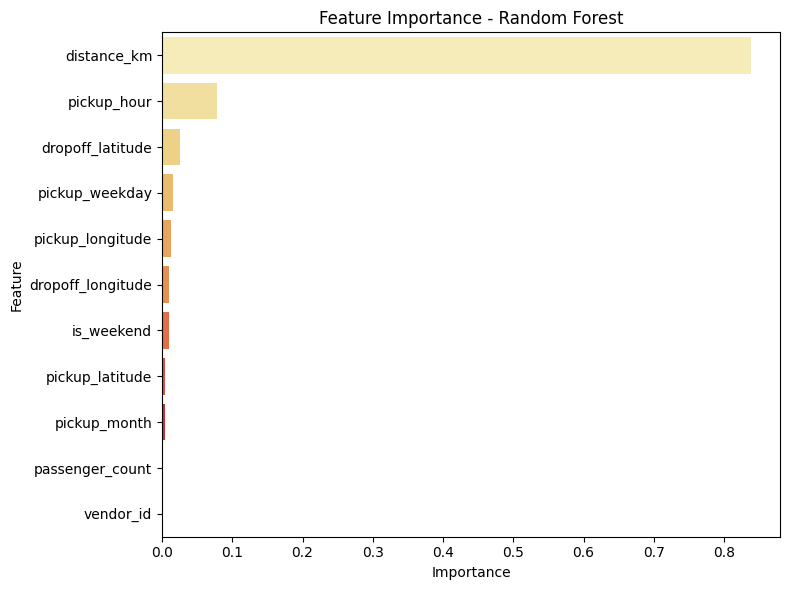

In [9]:
plt.figure(figsize=(8, 6))
sns.barplot(data = feature_importance, x = 'Importance', y = 'Feature', palette = 'YlOrRd', hue = 'Feature')
plt.title('Feature Importance - Random Forest')
plt.tight_layout()
plt.show()

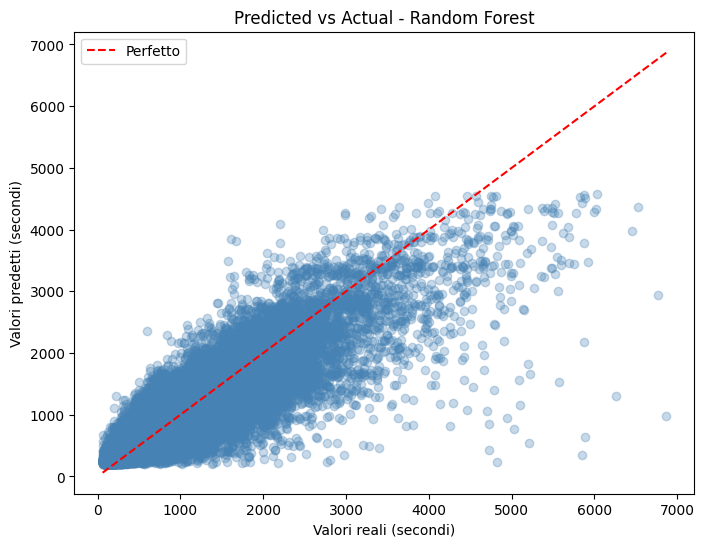

In [10]:
plt.figure(figsize = (8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.3, color = 'steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label = 'Perfetto')
plt.xlabel('Valori reali (secondi)')
plt.ylabel('Valori predetti (secondi)')
plt.title('Predicted vs Actual - Random Forest')
plt.legend()
plt.show()

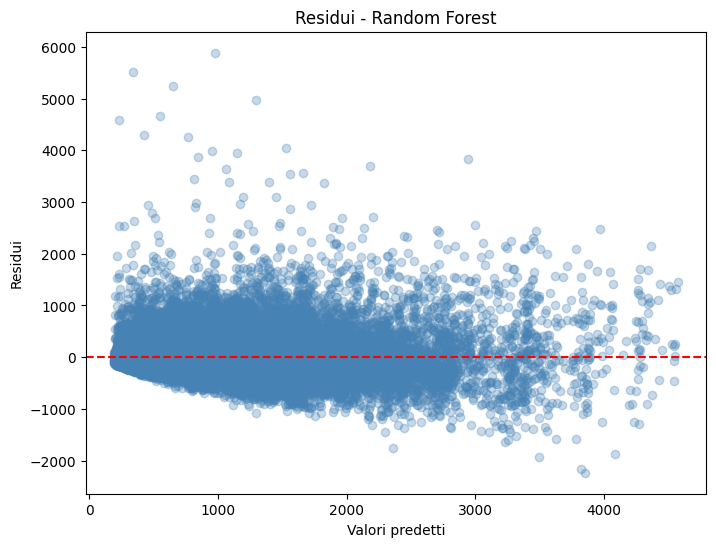

In [11]:
residui = y_test - y_pred_rf

plt.figure(figsize = (8, 6))
plt.scatter(y_pred_rf, residui, alpha=0.3, color = 'steelblue')
plt.axhline(0, color = 'red', linestyle='--')
plt.xlabel('Valori predetti')
plt.ylabel('Residui')
plt.title('Residui - Random Forest')
plt.show()

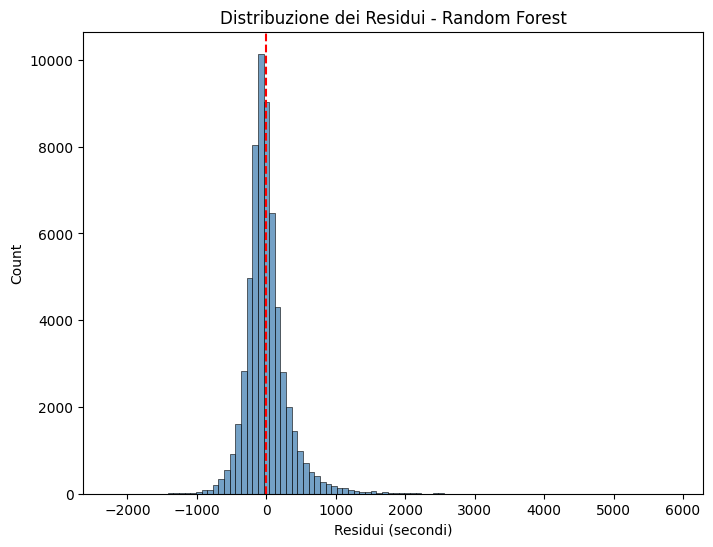

In [12]:
plt.figure(figsize = (8, 6))
sns.histplot(residui, bins = 100, color = 'steelblue')
plt.axvline(0, color = 'red', linestyle = '--')
plt.xlabel('Residui (secondi)')
plt.title('Distribuzione dei Residui - Random Forest')
plt.show()

In [13]:
from lightgbm import LGBMRegressor

# Definizione del modello
model_lgbm = LGBMRegressor(
    n_estimators = 100,
    learning_rate = 0.1,
    max_depth = -1,
    num_leaves = 31,
    subsample = 0.8,
    colsample_bytree = 0.8,
    n_jobs = -1,
    random_state = 42
)

model_lgbm.fit(X_train, y_train)
y_pred_lgbm = model_lgbm.predict(X_test)

# Metriche
mae_lgbm = mean_absolute_error(y_test, y_pred_lgbm)
rmse_lgbm = np.sqrt(mean_squared_error(y_test, y_pred_lgbm))
r2_lgbm = r2_score(y_test, y_pred_lgbm)

print("=" * 80)
print(f"MAE:  {mae_lgbm:.2f} secondi")
print(f"RMSE: {rmse_lgbm:.2f} secondi")
print(f"R²:   {r2_lgbm:.4f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.031433 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1325
[LightGBM] [Info] Number of data points in the train set: 240000, number of used features: 11
[LightGBM] [Info] Start training from score 842.553517
MAE:  198.20 secondi
RMSE: 303.15 secondi
R²:   0.7852


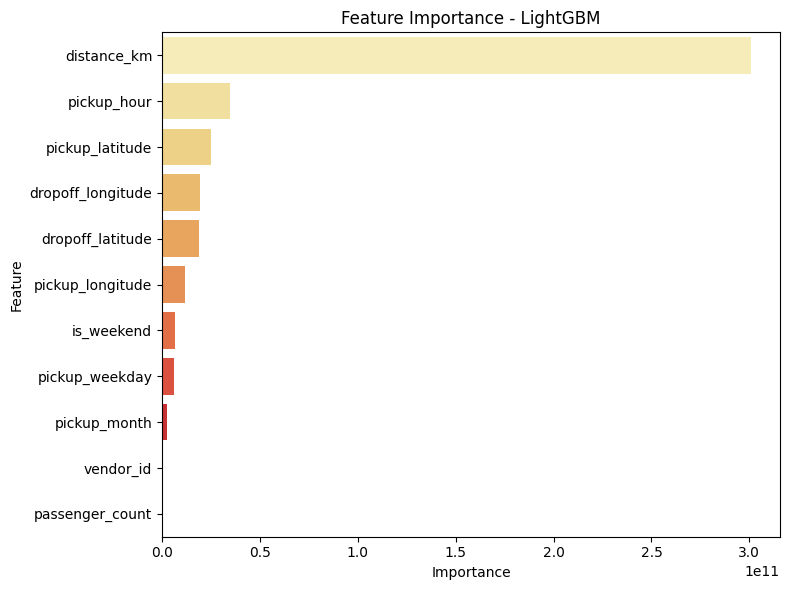

L'importanza delle Feature è:               Feature    Importance
1         distance_km  3.006224e+11
7         pickup_hour  3.464869e+10
3     pickup_latitude  2.510078e+10
4   dropoff_longitude  1.929622e+10
5    dropoff_latitude  1.887182e+10
2    pickup_longitude  1.198845e+10
6          is_weekend  6.615538e+09
9      pickup_weekday  5.969075e+09
8        pickup_month  2.679365e+09
10          vendor_id  8.731924e+07
0     passenger_count  4.585000e+07


In [14]:
# Feature Importance
feature_importance_lgbm = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model_lgbm.booster_.feature_importance(importance_type = 'gain')
}).sort_values("Importance", ascending = False)

plt.figure(figsize = (8, 6))
sns.barplot(data = feature_importance_lgbm, x = 'Importance', y = 'Feature', 
            palette = 'YlOrRd', hue = 'Feature')
plt.title('Feature Importance - LightGBM')
plt.tight_layout()
plt.show()

print(f"L'importanza delle Feature è: {feature_importance_lgbm}")

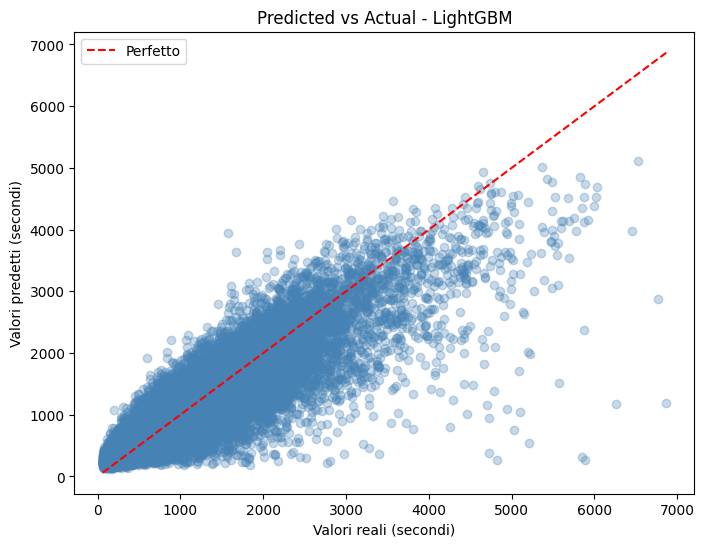

In [15]:
# Predicted vs Actual
plt.figure(figsize = (8, 6))
plt.scatter(y_test, y_pred_lgbm, alpha = 0.3, color = 'steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label = 'Perfetto')
plt.xlabel('Valori reali (secondi)')
plt.ylabel('Valori predetti (secondi)')
plt.title('Predicted vs Actual - LightGBM')
plt.legend()
plt.show()

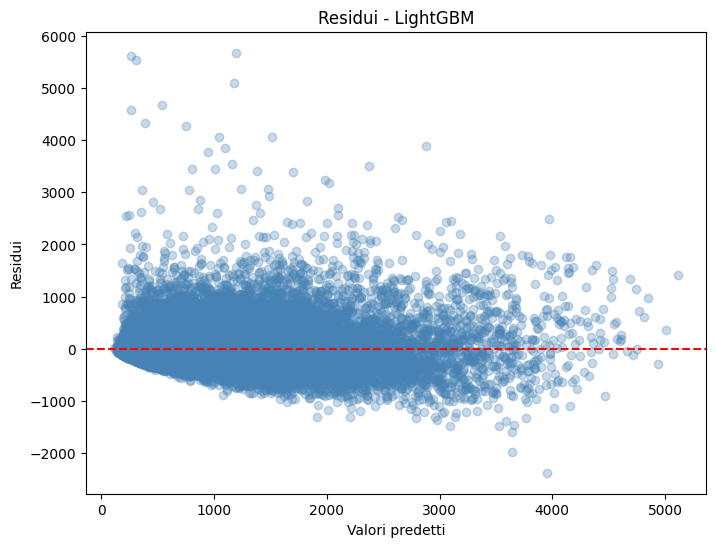

In [16]:
# Residui
residui_lgbm = y_test - y_pred_lgbm

plt.figure(figsize = (8, 6))
plt.scatter(y_pred_lgbm, residui_lgbm, alpha = 0.3, color = 'steelblue')
plt.axhline(0, color = 'red', linestyle = '--')
plt.xlabel('Valori predetti')
plt.ylabel('Residui')
plt.title('Residui - LightGBM')
plt.show()

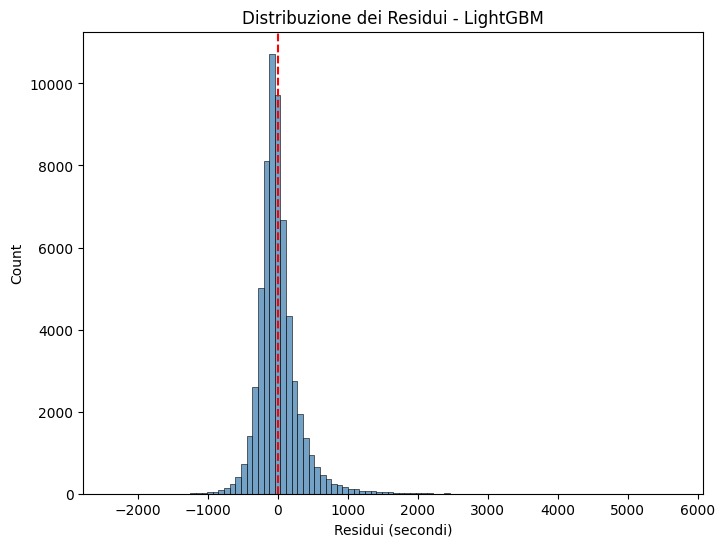

In [17]:
# Distribuzione residui
plt.figure(figsize = (8, 6))
sns.histplot(residui_lgbm, bins = 100, color = 'steelblue')
plt.axvline(0, color = 'red', linestyle = '--')
plt.xlabel('Residui (secondi)')
plt.title('Distribuzione dei Residui - LightGBM')
plt.show()

In [18]:
print("CONFRONTO MODELLI")
print("=" * 80)
print(f"{'Metrica':<10} {'Random Forest':>15} {'LightGBM':>15}")
print("-" * 40)
print(f"{'MAE':<10} {mae:.2f} sec {mae_lgbm:.2f} sec")
print(f"{'RMSE':<10} {rmse:.2f} sec {rmse_lgbm:.2f} sec")
print(f"{'R²':<10} {r2:.4f} {r2_lgbm:.4f}")

CONFRONTO MODELLI
Metrica      Random Forest        LightGBM
----------------------------------------
MAE        213.34 sec 198.20 sec
RMSE       323.27 sec 303.15 sec
R²         0.7558 0.7852


Notiamo che il modello migliore è il "LightGBM", rifacciamo quindi tutto il fit utilizzando il dataset completo

In [20]:
# Feature e target su tutto il dataset
X_full = df_clean[feature]
y_full = df_clean['trip_duration']

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_full, y_full, test_size = 0.2, random_state = 42
)

print(f"Training set: {X_train_full.shape[0]} righe")
print(f"Test set:     {X_test_full.shape[0]} righe")

Training set: 1152062 righe
Test set:     288016 righe


In [21]:
# Refit LightGBM su tutto il dataset
model_lgbm_full = LGBMRegressor(
    n_estimators = 300,
    learning_rate = 0.05,
    max_depth = -1,
    num_leaves = 50,
    subsample = 0.8,
    colsample_bytree = 0.8,
    n_jobs = -1,
    random_state = 42
)

model_lgbm_full.fit(X_train_full, y_train_full)
y_pred_lgbm_full = model_lgbm_full.predict(X_test_full)

mae_full = mean_absolute_error(y_test_full, y_pred_lgbm_full)
rmse_full = np.sqrt(mean_squared_error(y_test_full, y_pred_lgbm_full))
r2_full = r2_score(y_test_full, y_pred_lgbm_full)

print("=" * 80)
print(f"CONFRONTO - Sample 300k vs Full Dataset")
print("=" * 80)
print(f"{'Metrica':<10} {'LightGBM 300k':>15} {'LightGBM Full':>15}")
print("-" * 40)
print(f"{'MAE':<10} {mae_lgbm:.2f} sec {mae_full:.2f} sec")
print(f"{'RMSE':<10} {rmse_lgbm:.2f} sec {rmse_full:.2f} sec")
print(f"{'R²':<10} {r2_lgbm:.4f} {r2_full:.4f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.115032 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1325
[LightGBM] [Info] Number of data points in the train set: 1152062, number of used features: 11
[LightGBM] [Info] Start training from score 841.674156
CONFRONTO - Sample 300k vs Full Dataset
Metrica      LightGBM 300k   LightGBM Full
----------------------------------------
MAE        198.20 sec 188.98 sec
RMSE       303.15 sec 292.17 sec
R²         0.7852 0.7996


In [22]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [31, 50, 70, 100],
    'max_depth': [-1, 6, 8, 10],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

lgbm_search = RandomizedSearchCV(
    estimator = LGBMRegressor(n_jobs = -1, random_state = 42),
    param_distributions=param_grid,
    n_iter = 20,          # testa 20 combinazioni casuali
    scoring = 'r2',
    cv = 3,               # 3-fold cross validation
    n_jobs = -1,
    random_state = 42,
    verbose = 1           # stampa il progresso
)

lgbm_search.fit(X_train, y_train)  # usa il sample 300k per velocità

print(f"Migliori parametri: {lgbm_search.best_params_}")
print(f"Miglior R²: {lgbm_search.best_score_:.4f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011595 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1325
[LightGBM] [Info] Number of data points in the train set: 240000, number of used features: 11
[LightGBM] [Info] Start training from score 842.553517
Migliori parametri: {'subsample': 0.9, 'num_leaves': 50, 'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.9}
Miglior R²: 0.8021
